In [ ]:
import numpy as np
import tensorflow as tf
import math

# 1. Veri Üretimi
NUM_SAMPLES = 2000
np.random.seed(42)

# [0, 2*pi] aralığında rastgele x değerleri
x_values = np.random.uniform(low=0, high=2 * math.pi, size=NUM_SAMPLES)
np.random.shuffle(x_values)

# y = cos(x) + hafif gürültü
y_values = np.cos(x_values) + 0.05 * np.random.randn(NUM_SAMPLES)

# Train (%60), Validation (%20), Test (%20) bölme
TRAIN_SPLIT = int(0.6 * NUM_SAMPLES)
VAL_SPLIT = int(0.8 * NUM_SAMPLES)

x_train, x_val, x_test = np.split(x_values, [TRAIN_SPLIT, VAL_SPLIT])
y_train, y_val, y_test = np.split(y_values, [TRAIN_SPLIT, VAL_SPLIT])

# 2. Küçük Model Mimarisi Oluşturma
model = tf.keras.Sequential([
    tf.keras.layers.Dense(16, activation='relu', input_shape=(1,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# 3. Model Eğitimi
history = model.fit(
    x_train, y_train,
    epochs=250,
    batch_size=32,
    validation_data=(x_val, y_val),
    verbose=0
)

loss, mae = model.evaluate(x_test, y_test, verbose=0)
print(f"Test MAE: {mae:.4f}")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test MAE: 0.0598


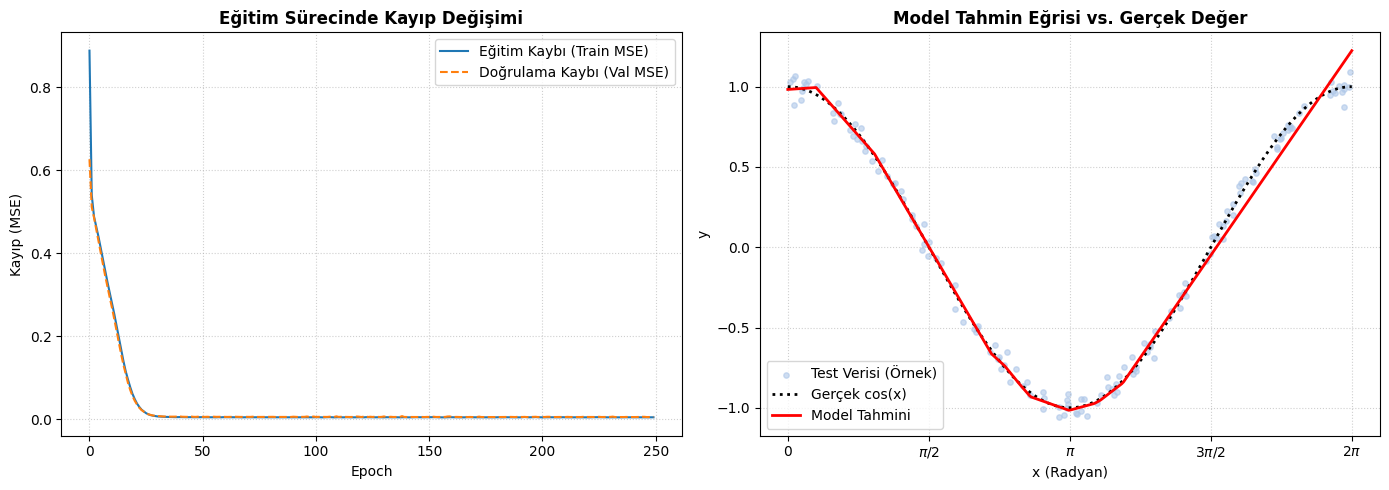

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import math

# 1. Eğitim ve Doğrulama Kaybı Grafiği
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı (Train MSE)', color='#1f77b4')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı (Val MSE)', linestyle='--', color='#ff7f0e')
plt.title('Eğitim Sürecinde Kayıp Değişimi', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Kayıp (MSE)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

# 2. Modelin Tahmini vs Gerçek Fonksiyon
plt.subplot(1, 2, 2)
x_dense = np.linspace(0, 2 * math.pi, 300)
y_dense_pred = model.predict(x_dense, verbose=0)

plt.scatter(x_test[:150], y_test[:150], color='#aec7e8', alpha=0.6, s=15, label='Test Verisi (Örnek)')
plt.plot(x_dense, np.cos(x_dense), 'k:', linewidth=2, label='Gerçek cos(x)')
plt.plot(x_dense, y_dense_pred, 'r-', linewidth=2, label='Model Tahmini')
plt.title('Model Tahmin Eğrisi vs. Gerçek Değer', fontweight='bold')
plt.xlabel('x (Radyan)')
plt.ylabel('y')
plt.xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi], ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$'])
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Temsili veri kümesi (Kuantizasyon kalibrasyonu için)
def representative_dataset():
    for val in x_train[:100]:
        yield [np.array([val], dtype=np.float32)]

# TFLite Dönüştürücüsü
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_quant_model = converter.convert()

# TFLite modelini C dizisi (model_data.h) olarak kaydetme
def convert_to_c_array(bytes_data, array_name="model_data"):
    hex_str = ", ".join(f"0x{b:02x}" for b in bytes_data)
    header_content = f"""#ifndef MODEL_DATA_H
#define MODEL_DATA_H

const unsigned char {array_name}[] = {{ {hex_str} }};
const unsigned int {array_name}_len = {len(bytes_data)};

#endif // MODEL_DATA_H
"""
    with open("model_data.h", "w") as f:
        f.write(header_content)

convert_to_c_array(tflite_quant_model)
print("model_data.h dosyası oluşturuldu.")

Saved artifact at '/tmp/tmp9sju7p1j'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  133121487565840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133121487566800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133121487566416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133121487567184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133121487566992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133121487567568: TensorSpec(shape=(), dtype=tf.resource, name=None)


/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


model_data.h dosyası oluşturuldu.
